<a href="https://colab.research.google.com/github/Jenyy0416/cs1090b_project/blob/tiff/ms3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CS 1090B Project Milestone 3

*Group project number:* 41

*Group members:* You Wu, Jenny Yang, Xuyang Sun, Yifan Xu, Jiaxi Liu

 # 1. Problem Statement Refinement and introduction:


## Redefinition & Rescoping of the Problem Statement

The original project proposal framed this task as a chest X-ray image-to-text problem, with the goal of generating short medical findings from paired radiology images and reports in the dataset. The proposed workflow used a deep learning pipeline with an image encoder to extract visual features from chest X-rays, a sequence decoder to generate report text, next-token prediction as the training objective, and BLEU and ROUGE as evaluation metrics.

After preprocessing and exploratory data analysis, we refined this initial idea to better match the actual structure and limitations of the cleaned dataset. In particular, the text fields are not equally suitable for generation: the `findings` section is longer, noisier, and more incomplete, whereas the `impression` section is shorter, more standardized, and more consistently available. In addition, the cleaned dataset contains only a few thousand valid studies, which makes full report generation or highly complex modeling less realistic for the current project scope. For this reason, we narrow the task from generating full findings to generating a short impression summary, which is both more feasible and more aligned with the quality of the data we retained.

Based on these observations, our revised research question is: **Can a model generate a short, clinically plausible impression summary from chest X-ray images, and does using both frontal and lateral views improve performance over a frontal-only baseline?** This question is more specific and better grounded in the dataset than the original proposal because it focuses on the cleaner target text and introduces a meaningful comparison between single-view and multi-view image input. Rather than assuming that a more complex setup will always help, this formulation allows us to test whether the extra lateral view provides enough additional information to justify the added modeling complexity.

This revised question also keeps the modeling strategy intentionally flexible. At this stage, the project does not require committing in advance to either training entirely on the cleaned dataset or relying on a pretrained model with fine-tuning. Instead, the central goal is to evaluate whether the available chest X-ray images contain enough signal to support short clinical summary generation under a realistic data constraint. Any model choice should therefore be treated as a means to answer this question, rather than as the main contribution of the project itself.

# 2. Comprehensive EDA Review:

## Image EDA

In [6]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
from datasets import load_from_disk

NOTEBOOK_ROOT = Path("/content/drive/MyDrive/cs109b_project")
DATA_DIR = NOTEBOOK_ROOT / "ds_cleaned_hf"

dataset = load_from_disk(str(DATA_DIR))
data = dataset


Mounted at /content/drive


### Sample Visualization


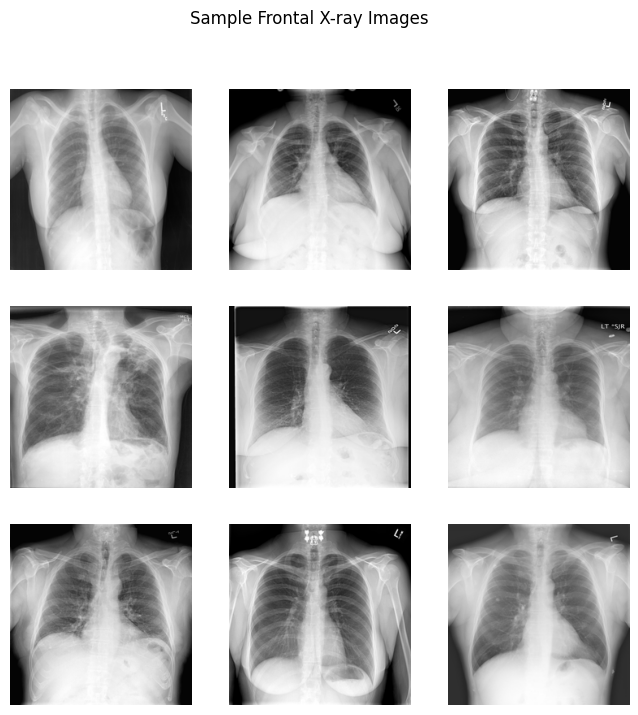

In [7]:
fig, axes = plt.subplots(3, 3, figsize=(8, 8))

for i, ax in enumerate(axes.flat):
    img = data[i]["img_frontal_processed"]
    ax.imshow(img)
    ax.axis("off")

plt.suptitle("Sample Frontal X-ray Images")
plt.show()

The sample frontal X-ray images show consistent anatomical structures, including clear lung fields, rib boundaries, and heart silhouettes.

There is visible variability across samples, with some images showing potential abnormalities such as opacities or asymmetry, suggesting the dataset contains both normal and pathological cases.

The images are centered and aligned, indicating successful preprocessing and suitability for downstream modeling.

In [8]:
sizes = []

for i in range(len(data)):
    img = data[i]["img_frontal_processed"]
    sizes.append(img.size)

set(sizes)

{(224, 224)}